lambda = 1.0

A =
[[0.1+0.j 0.3+0.j 0.2+0.j 0.4+0.j]
 [0.3+0.j 0.1+0.j 0.4+0.j 0.2+0.j]
 [0.2+0.j 0.4+0.j 0.1+0.j 0.3+0.j]
 [0.4+0.j 0.2+0.j 0.3+0.j 0.1+0.j]]

LCU BLOCK ENCODING U(A):


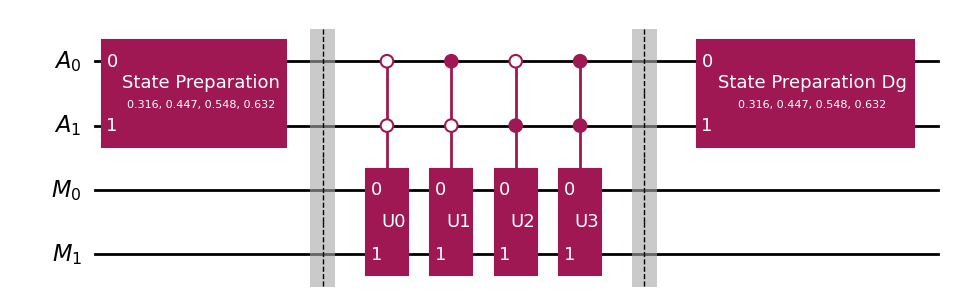


Is U(A) unitary?
True

|00><00| block of U(A):
[[0.1+0.j 0.3+0.j 0.2-0.j 0.4-0.j]
 [0.3-0.j 0.1-0.j 0.4-0.j 0.2-0.j]
 [0.2-0.j 0.4-0.j 0.1+0.j 0.3-0.j]
 [0.4-0.j 0.2-0.j 0.3+0.j 0.1+0.j]]

Expected A/lambda:
[[0.1+0.j 0.3+0.j 0.2+0.j 0.4+0.j]
 [0.3+0.j 0.1+0.j 0.4+0.j 0.2+0.j]
 [0.2+0.j 0.4+0.j 0.1+0.j 0.3+0.j]
 [0.4+0.j 0.2+0.j 0.3+0.j 0.1+0.j]]

Does block encoding work?
True

QSVT phases:
phi_1 = 0.5235987755982988
phi_2 = 0.7853981633974483
phi_3 = 1.0471975511965976
phi_4 = 1.5707963267948966
phi_5 = 3.141592653589793

Example Pi_phi1 diagonal:
[0.866+0.5j 0.866-0.5j 0.866-0.5j 0.866-0.5j 0.866+0.5j 0.866-0.5j
 0.866-0.5j 0.866-0.5j 0.866+0.5j 0.866-0.5j 0.866-0.5j 0.866-0.5j
 0.866+0.5j 0.866-0.5j 0.866-0.5j 0.866-0.5j]

QSVT CIRCUIT:


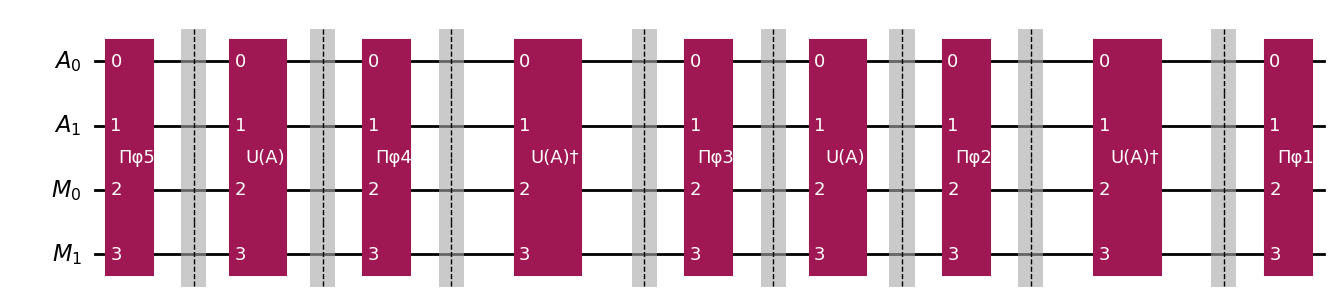


Is complete QSVT operator unitary?
True

--------------------------------------
QSVT TRANSFORMED BLOCK
--------------------------------------
[[-0.177025+0.523825j  0.252339+0.101823j  0.454768-0.101823j
   0.177025+0.183282j]
 [ 0.252339+0.101823j -0.177025+0.523825j  0.177025+0.183282j
   0.454768-0.101823j]
 [ 0.454768-0.101823j  0.177025+0.183282j -0.177025+0.523825j
   0.252339+0.101823j]
 [ 0.177025+0.183282j  0.454768-0.101823j  0.252339+0.101823j
  -0.177025+0.523825j]]

Original A:
[[0.1+0.j 0.3+0.j 0.2+0.j 0.4+0.j]
 [0.3+0.j 0.1+0.j 0.4+0.j 0.2+0.j]
 [0.2+0.j 0.4+0.j 0.1+0.j 0.3+0.j]
 [0.4+0.j 0.2+0.j 0.3+0.j 0.1+0.j]]

Eigenvalues of A:
[-0.4 -0.2  0.   1. ]

Eigenvalues of transformed block P(A):
[ 0.707107+0.707107j -0.151621+0.136896j -0.707107+0.707107j
 -0.556478+0.544189j]


In [ ]:
from qiskit import QuantumRegister, QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate, StatePreparation
from IPython.display import display
import numpy as np
from numpy import pi



# 1. PAULI MATRICES


I = np.eye(2, dtype=complex)

X = np.array([
    [0, 1],
    [1, 0]
], dtype=complex)



# 2. FOUR PAULI TERMS


U0 = np.kron(I, I)    # II
U1 = np.kron(X, I)    # XI
U2 = np.kron(I, X)    # IX
U3 = np.kron(X, X)    # XX

U_list = [U0, U1, U2, U3]



# 3. COEFFICIENTS


alpha = np.array([
    0.1,
    0.2,
    0.3,
    0.4
], dtype=float)

lam = np.sum(alpha)

print("lambda =", lam)



# 4. MATRIX A


A = sum(
    alpha[x] * U_list[x]
    for x in range(4)
)

print("\nA =")
print(np.round(A, 4))



# 5. REGISTERS FOR BLOCK ENCODING


anc = QuantumRegister(2, 'A')
main = QuantumRegister(2, 'M')

U_circuit = QuantumCircuit(anc, main)



# 6. PREP


prep_amplitudes = np.sqrt(alpha / lam)

PREP = StatePreparation(prep_amplitudes)

U_circuit.append(PREP, anc)

U_circuit.barrier()



# 7. SELECT


for x in range(4):

    gate = UnitaryGate(
        U_list[x],
        label=f'U{x}'
    )

    controlled_gate = gate.control(
        num_ctrl_qubits=2,
        ctrl_state=x
    )

    U_circuit.append(
        controlled_gate,
        [
            anc[0],
            anc[1],
            main[0],
            main[1]
        ]
    )


U_circuit.barrier()



# 8. PREP dagger


U_circuit.append(
    PREP.inverse(),
    anc
)


print("\nLCU BLOCK ENCODING U(A):")
display(U_circuit.draw('mpl'))



# 9. MATRIX OF THE BLOCK-ENCODING UNITARY


U_matrix = Operator(U_circuit).data


print("\nIs U(A) unitary?")

print(
    np.allclose(
        U_matrix.conj().T @ U_matrix,
        np.eye(16)
    )
)



# 10. EXTRACT THE |00> ANCILLA BLOCK
#
# Qiskit basis ordering:
#
# |M1 M0 A1 A0>
#
# Ancilla = 00 therefore corresponds to indices
#
# 0, 4, 8, 12


indices_00 = [0, 4, 8, 12]

block_A = U_matrix[
    np.ix_(indices_00, indices_00)
]


print("\n|00><00| block of U(A):")
print(np.round(block_A, 4))


print("\nExpected A/lambda:")
print(np.round(A / lam, 4))


print("\nDoes block encoding work?")

print(
    np.allclose(
        block_A,
        A / lam
    )
)



# 11. QSVT PHASES
#
# d = 4
#
# therefore d+1 = 5 phases


phi1 = pi / 6
phi2 = pi / 4
phi3 = pi / 3
phi4 = pi / 2
phi5 = pi

phis = [
    phi1,
    phi2,
    phi3,
    phi4,
    phi5
]

print("\nQSVT phases:")

for k, phi in enumerate(phis, start=1):
    print(f"phi_{k} = {phi}")



# 12. PROJECTOR-CONTROLLED PHASE
#
# Π_phi =
#
# e^(+i phi)   on ancilla |00>
#
# e^(-i phi)   on all states orthogonal to |00>
#
#
# Π = |00><00|_A tensor I_M
#
#
# Π_phi =
#
# exp[i phi (2Π - I)]
#
# =
#
# e^(i phi) Π
# +
# e^(-i phi)(I - Π)
#


def projector_phase_matrix(phi):

    D = np.zeros(
        (16, 16),
        dtype=complex
    )

    for index in range(16):

        basis = format(index, '04b')

        # Qiskit ordering:
        #
        # |M1 M0 A1 A0>
        #
        # therefore last two bits are ancillas

        ancilla_bits = basis[-2:]

        if ancilla_bits == '00':

            D[index, index] = np.exp(1j * phi)

        else:

            D[index, index] = np.exp(-1j * phi)

    return D



# 13. CHECK ONE PROJECTOR PHASE MATRIX


Pi_test = projector_phase_matrix(phi1)

print("\nExample Pi_phi1 diagonal:")

print(
    np.round(
        np.diag(Pi_test),
        4
    )
)



# 14. CREATE PROJECTOR-PHASE GATE


def projector_phase_gate(phi, label):

    matrix = projector_phase_matrix(phi)

    return UnitaryGate(
        matrix,
        label=label
    )



# 15. CREATE U(A) AND U(A) dagger AS GATES


U_gate = UnitaryGate(
    U_matrix,
    label='U(A)'
)

U_dagger_gate = UnitaryGate(
    U_matrix.conj().T,
    label='U(A)†'
)



# 16. QSVT CIRCUIT


anc_qsvt = QuantumRegister(2, 'A')
main_qsvt = QuantumRegister(2, 'M')

qsvt = QuantumCircuit(
    anc_qsvt,
    main_qsvt
)

all_qubits = [
    anc_qsvt[0],
    anc_qsvt[1],
    main_qsvt[0],
    main_qsvt[1]
]



# EVEN QSVT, d = 4
#
# Mathematical product:
#
# Π_phi1 U† Π_phi2 U
# Π_phi3 U† Π_phi4 U
# Π_phi5
#
#
# Qiskit time order must therefore be:
#
# Π_phi5
# U
# Π_phi4
# U†
# Π_phi3
# U
# Π_phi2
# U†
# Π_phi1



qsvt.append(
    projector_phase_gate(phi5, 'Πφ5'),
    all_qubits
)

qsvt.barrier()


qsvt.append(
    U_gate,
    all_qubits
)

qsvt.barrier()


qsvt.append(
    projector_phase_gate(phi4, 'Πφ4'),
    all_qubits
)

qsvt.barrier()


qsvt.append(
    U_dagger_gate,
    all_qubits
)

qsvt.barrier()


qsvt.append(
    projector_phase_gate(phi3, 'Πφ3'),
    all_qubits
)

qsvt.barrier()


qsvt.append(
    U_gate,
    all_qubits
)

qsvt.barrier()


qsvt.append(
    projector_phase_gate(phi2, 'Πφ2'),
    all_qubits
)

qsvt.barrier()


qsvt.append(
    U_dagger_gate,
    all_qubits
)

qsvt.barrier()


qsvt.append(
    projector_phase_gate(phi1, 'Πφ1'),
    all_qubits
)



# 17. DRAW QSVT CIRCUIT


print("\nQSVT CIRCUIT:")

display(
    qsvt.draw(
        'mpl',
        fold=-1
    )
)



# 18. FULL QSVT MATRIX


QSVT_matrix = Operator(qsvt).data


print("\nIs complete QSVT operator unitary?")

print(
    np.allclose(
        QSVT_matrix.conj().T @ QSVT_matrix,
        np.eye(16)
    )
)



# 19. EXTRACT THE ANCILLA |00> BLOCK
#
# This is the transformed matrix.
#
# According to QSVT:
#
# <00| QSVT |00> = P(A)
#
# for the polynomial associated with these phases.


P_of_A = QSVT_matrix[
    np.ix_(
        indices_00,
        indices_00
    )
]


print("\n--------------------------------------")
print("QSVT TRANSFORMED BLOCK")
print("--------------------------------------")

print(
    np.round(
        P_of_A,
        6
    )
)



# 20. ORIGINAL A


print("\nOriginal A:")

print(
    np.round(
        A,
        6
    )
)



# 21. EIGENVALUES OF A


eigvals_A = np.linalg.eigvalsh(A)

print("\nEigenvalues of A:")

print(
    np.round(
        eigvals_A,
        6
    )
)



# 22. EIGENVALUES OF QSVT-TRANSFORMED BLOCK


eigvals_P = np.linalg.eigvals(P_of_A)

print("\nEigenvalues of transformed block P(A):")

print(
    np.round(
        eigvals_P,
        6
    )
)